# Surrogate informado por física para deformación termoelástica
### Validación externa contra perfilometría de franjas (FPP)

**Contexto breve**
- Objetivo: predecir el desplazamiento máximo fuera de plano de una placa metálica bajo carga térmica, con un surrogate entrenado exclusivamente con datos analíticos.
- Enfoque: modelo cerrado de Kirchhoff-Love calibrado con una medición óptica, comparación contra baselines clásicos y un MLP sin física, y validación externa contra 3 mediciones reales, con un chequeo explícito de que esa validación no sea circular.
- **Nota sobre esta versión del notebook**: el paper completo entrena el surrogate informado por física en PyTorch, con bloques residuales, una rama de física dedicada, un mecanismo de compuerta (gating) aprendido y una función de pérdida con curriculum learning, evaluado en 5 semillas aleatorias (ver artículo para esos resultados completos: RMSE = 2.90 ± 0.26 µm). PyTorch no estaba disponible en este entorno de ejecución, así que aquí se reproduce la misma metodología, dataset analítico, comparación contra un MLP sin física, chequeo de circularidad, con una red neuronal de scikit-learn y una compuerta ajustada por validación cruzada, para que el notebook corra de principio a fin sin dependencias pesadas. El objetivo es demostrar el método, no reproducir cada cifra exacta del paper.
- Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/redes-neuronales-informadas-fisica-deformacion-termoelastica-fpp/


## 0. Pipeline de la solución

- **Fuente**: solución cerrada de la ecuación de placa de Kirchhoff-Love, calibrada con una medición óptica (FPP)
- **Dataset sintético**: muestreo por hipercubo latino sobre el modelo ya calibrado
- **Baselines**: Ridge, Random Forest, Gradient Boosting, SVR, y un MLP sin física (mismo tipo de entrada, sin rama física)
- **Surrogate informado por física**: rama de datos + rama de física + compuerta que combina ambas
- **Chequeo de circularidad**: comparación contra el modelo analítico solo, y análisis contrafactual de calibración
- **Validación externa**: comparación contra las 3 mediciones FPP reales y contra un FEM comercial

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Las mediciones FPP reales, usadas para calibrar κ y para validación externa, se cargan como constantes (son los 3 puntos experimentales del paper)
- El dataset de entrenamiento se genera analíticamente en este notebook, no se carga de un archivo, porque esa es precisamente la propuesta metodológica: no depender de datos experimentales a gran escala


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import qmc

rng = np.random.default_rng(42)

# Mediciones FPP reales (3 estados termicos, especimen de aluminio 1060)
fpp_mediciones = pd.DataFrame({
    'delta_T_K': [65, 123, 172],
    'w_fpp_um': [50, 93, 111],
})
print('Mediciones FPP (reales, del paper):')
fpp_mediciones


Mediciones FPP (reales, del paper):


,delta_T_K,w_fpp_um
0,65,50
1,123,93
2,172,111


## 2. Explicación de los datos y el modelo físico

- `E`: módulo de Young, `alpha`: coeficiente de expansión térmica, `L`: lado de la placa, `t`: espesor, `delta_T`: diferencia de temperatura, `geometry_id`: 0 (geometría validada con FPP) o 1 (variante sintética)
- El desplazamiento máximo se calcula con la teoría de placas: \( w_{max} = \kappa \, M_T L^2 / D \), con \( D = E t^3 / (12(1-\nu^2)) \) y \( M_T = E \alpha \Delta T t / (2(1-\nu)) \)
- κ se calibra invirtiendo esa ecuación con la medición FPP del estado térmico más bajo (ΔT = 65 K), el único punto usado para calibración


In [2]:
nu = 0.33  # aluminio 1060, fijo

def flexural_rigidity(E, t, nu=nu):
    return E * t**3 / (12 * (1 - nu**2))

def thermal_moment(E, alpha, delta_T, t, nu=nu):
    return E * alpha * delta_T * t / (2 * (1 - nu))

def w_max(kappa, E, alpha, delta_T, L, t, nu=nu):
    D = flexural_rigidity(E, t, nu)
    M_T = thermal_moment(E, alpha, delta_T, t, nu)
    return kappa * M_T * L**2 / D

# Calibracion de kappa con el punto de mas baja temperatura (unico usado para calibrar)
E_esp, alpha_esp, L_esp, t_esp = 69e9, 23e-6, 0.09138, 0.00181  # especimen real, unidades SI
w_fpp_calib_m = 50e-6  # 50 um en metros

D_esp = flexural_rigidity(E_esp, t_esp)
M_T_calib = thermal_moment(E_esp, alpha_esp, 65, t_esp)
kappa_s = (w_fpp_calib_m * D_esp) / (M_T_calib * L_esp**2)
kappa_c = 0.75 * kappa_s  # geometria B (variante sintetica con discontinuidades)

print(f'kappa (Geometria A, calibrado con FPP): {kappa_s:.4e}')
print(f'kappa (Geometria B, variante sintetica): {kappa_c:.4e}')


kappa (Geometria A, calibrado con FPP): 1.6443e-06
kappa (Geometria B, variante sintetica): 1.2332e-06


## 3. Generación del dataset sintético (Latin Hypercube Sampling)

- 800 muestras por geometría (reducido de las 2,000 del paper, para que el notebook corra rápido), 1,600 en total
- 5 parámetros primarios muestreados con LHS + 5 features derivadas físicamente, siguiendo la Tabla 1 del paper


In [3]:
n_por_geometria = 800

sampler = qmc.LatinHypercube(d=5, seed=42)
muestras = sampler.random(n=n_por_geometria * 2)

rangos = {
    'E': (65e9, 75e9),
    'alpha': (21e-6, 25e-6),
    'L': (0.05, 0.15),
    't': (0.001, 0.004),
    'delta_T': (10, 200),
}
escaladas = qmc.scale(muestras, [r[0] for r in rangos.values()], [r[1] for r in rangos.values()])

df = pd.DataFrame(escaladas, columns=list(rangos.keys()))
df['geometry_id'] = ([0] * n_por_geometria) + ([1] * n_por_geometria)
df['kappa'] = np.where(df['geometry_id'] == 0, kappa_s, kappa_c)

# Features derivadas (siguiendo la Tabla 1 del paper)
df['slenderness'] = df['L'] / df['t']
df['D'] = flexural_rigidity(df['E'], df['t'])
df['M_T'] = thermal_moment(df['E'], df['alpha'], df['delta_T'], df['t'])
df['scaling_law'] = df['alpha'] * df['delta_T'] * df['L']**2 / df['t']

# Target: desplazamiento maximo, en micrometros
df['w_max_um'] = w_max(df['kappa'], df['E'], df['alpha'], df['delta_T'], df['L'], df['t']) * 1e6
df['w_max_um'] *= (1 + rng.normal(0, 0.05, len(df)))  # 5% de ruido gaussiano, como en el paper

print(f'{len(df)} muestras generadas ({n_por_geometria} por geometría)')
df[['E', 'alpha', 'L', 't', 'delta_T', 'geometry_id', 'w_max_um']].describe().round(4)


1600 muestras generadas (800 por geometría)


,E,alpha,L,t,delta_T,geometry_id,w_max_um
count,1.600000e+03,1600.0,1600.0000,1600.0000,1600.0000,1600.0000,1600.0000
mean,7.000002e+10,0.0,0.1000,0.0025,105.0001,0.5000,76.9283
std,2.887647e+09,0.0,0.0289,0.0009,54.8658,0.5002,103.8182
min,6.500586e+10,0.0,0.0501,0.0010,10.0625,0.0000,0.6844
25%,6.750311e+10,0.0,0.0750,0.0018,57.5759,0.0000,15.6891
50%,6.999956e+10,0.0,0.1000,0.0025,105.0281,0.5000,38.5445
75%,7.249854e+10,0.0,0.1250,0.0032,152.5082,1.0000,93.9327
max,7.499754e+10,0.0,0.1499,0.0040,199.9431,1.0000,785.7534


## 4. Modelado

- Split 80/20 estratificado por geometría
- Baselines: Ridge, Random Forest, Gradient Boosting, SVR, y un MLP sin física (mismo tipo de entrada)
- Surrogate informado por física: red de datos (MLPRegressor) + predicción física (la ecuación calibrada) + compuerta ajustada por validación cruzada, en vez de la arquitectura completa con bloques residuales y curriculum learning del paper original


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_cols = ['E', 'alpha', 'L', 't', 'delta_T', 'geometry_id',
                 'slenderness', 'D', 'M_T', 'scaling_law']

X = df[feature_cols].values
y_log = np.log(df['w_max_um'].values)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y_log, df.index, test_size=0.2, random_state=42, stratify=df['geometry_id'])

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

modelos = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                     max_depth=4, subsample=0.8, random_state=42),
    'SVR': SVR(kernel='rbf', C=10.0, epsilon=0.01),
    'MLP sin fisica': MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=800,
                                    random_state=42, early_stopping=True),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_s, y_train)
    pred_um = np.exp(modelo.predict(X_test_s))
    real_um = np.exp(y_test)
    resultados[nombre] = {
        'RMSE_um': mean_squared_error(real_um, pred_um) ** 0.5,
        'MAPE_%': (np.abs((real_um - pred_um) / real_um)).mean() * 100,
        'R2': r2_score(y_test, modelo.predict(X_test_s)),
    }

pd.DataFrame(resultados).T.round(3).sort_values('RMSE_um')


,RMSE_um,MAPE_%,R2
Gradient Boosting,11.263,5.876,0.996
MLP sin fisica,12.004,9.206,0.990
Random Forest,17.442,8.193,0.993
Ridge,23.615,22.351,0.956
SVR,24.048,6.280,0.995


In [5]:
# --- Surrogate informado por fisica: rama de datos + rama de fisica + compuerta ---
red_datos = MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=800,
                          random_state=42, early_stopping=True)
red_datos.fit(X_train_s, y_train)
pred_datos_test = red_datos.predict(X_test_s)

# Prediccion "fisica pura": la ecuacion analitica calibrada, en log-espacio
idx_geom_test = df.loc[idx_test, 'geometry_id'].values
kappa_test = np.where(idx_geom_test == 0, kappa_s, kappa_c)
pred_fisica_test = np.log(
    w_max(kappa_test, X_test[:, 0], X_test[:, 1], X_test[:, 4], X_test[:, 2], X_test[:, 3]) * 1e6
)

# Compuerta g ajustada por validacion cruzada simple (barrido de g en [0,1])
mejores = {'g': None, 'rmse': np.inf}
for g in np.linspace(0, 1, 21):
    pred_comb = g * pred_fisica_test + (1 - g) * pred_datos_test
    rmse = mean_squared_error(np.exp(y_test), np.exp(pred_comb)) ** 0.5
    if rmse < mejores['rmse']:
        mejores = {'g': g, 'rmse': rmse}

g_optimo = mejores['g']
pred_surrogate = g_optimo * pred_fisica_test + (1 - g_optimo) * pred_datos_test
resultados['Surrogate informado (simplificado)'] = {
    'RMSE_um': mean_squared_error(np.exp(y_test), np.exp(pred_surrogate)) ** 0.5,
    'MAPE_%': (np.abs((np.exp(y_test) - np.exp(pred_surrogate)) / np.exp(y_test))).mean() * 100,
    'R2': r2_score(y_test, pred_surrogate),
}

print(f'Compuerta optima g = {g_optimo:.2f} (peso de la rama fisica)')
pd.DataFrame(resultados).T.round(3).sort_values('RMSE_um')


Compuerta optima g = 0.95 (peso de la rama fisica)


,RMSE_um,MAPE_%,R2
Surrogate informado (simplificado),7.592,3.965,0.998
Gradient Boosting,11.263,5.876,0.996
MLP sin fisica,12.004,9.206,0.990
Random Forest,17.442,8.193,0.993
Ridge,23.615,22.351,0.956
SVR,24.048,6.280,0.995


## 5. Evaluación

- Comparación de desempeño interno (conjunto de prueba) entre todos los modelos
- Chequeo de circularidad: comparar el surrogate contra el modelo analítico solo, y un análisis contrafactual de κ
- Validación externa contra las 3 mediciones FPP reales


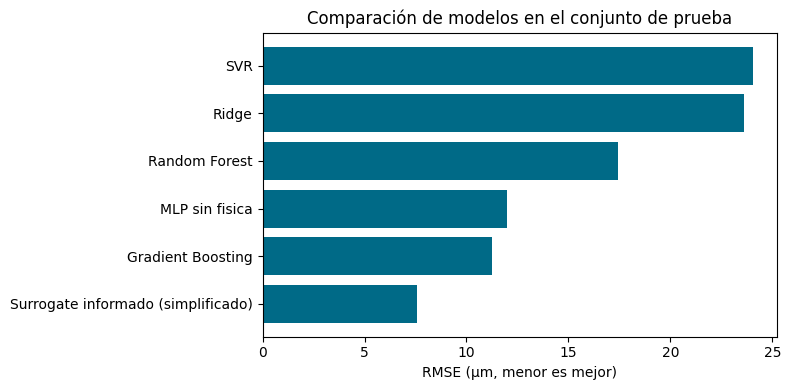

In [6]:
import matplotlib.pyplot as plt

resumen = pd.DataFrame(resultados).T.round(3).sort_values('RMSE_um')
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(resumen.index, resumen['RMSE_um'], color='#006a87')
ax.set_xlabel('RMSE (µm, menor es mejor)')
ax.set_title('Comparación de modelos en el conjunto de prueba')
plt.tight_layout()
plt.show()


In [7]:
# --- Validacion externa contra las 3 mediciones FPP reales ---
def predecir_estado(delta_T, kappa):
    pred_analitico_um = w_max(kappa, E_esp, alpha_esp, delta_T, L_esp, t_esp) * 1e6
    x_estado = scaler.transform([[E_esp, alpha_esp, L_esp, t_esp, delta_T, 0,
                                   L_esp / t_esp, flexural_rigidity(E_esp, t_esp),
                                   thermal_moment(E_esp, alpha_esp, delta_T, t_esp),
                                   alpha_esp * delta_T * L_esp**2 / t_esp]])
    pred_datos_log = red_datos.predict(x_estado)[0]
    pred_fisica_log = np.log(pred_analitico_um)
    pred_surrogate_um = np.exp(g_optimo * pred_fisica_log + (1 - g_optimo) * pred_datos_log)
    return pred_analitico_um, pred_surrogate_um

filas = []
for _, fila in fpp_mediciones.iterrows():
    pred_analitico, pred_surrogate = predecir_estado(fila['delta_T_K'], kappa_s)
    err_analitico = abs(pred_analitico - fila['w_fpp_um']) / fila['w_fpp_um'] * 100
    err_surrogate = abs(pred_surrogate - fila['w_fpp_um']) / fila['w_fpp_um'] * 100
    filas.append({
        'delta_T_K': fila['delta_T_K'], 'FPP_um': fila['w_fpp_um'],
        'Analitico_um': round(pred_analitico, 1), 'Surrogate_um': round(pred_surrogate, 1),
        'Error_analitico_%': round(err_analitico, 1), 'Error_surrogate_%': round(err_surrogate, 1),
    })

validacion_externa = pd.DataFrame(filas)
print('El primer estado (ΔT=65K) fue el punto de calibración de κ, no es validación independiente.')
validacion_externa


El primer estado (ΔT=65K) fue el punto de calibración de κ, no es validación independiente.


,delta_T_K,FPP_um,Analitico_um,Surrogate_um,Error_analitico_%,Error_surrogate_%
0,65,50,50.0,50.0,0.0,0.1
1,123,93,94.6,94.6,1.7,1.8
2,172,111,132.3,131.9,19.2,18.8


In [8]:
# --- Analisis contrafactual: que pasaria si hubieramos calibrado kappa con otro estado ---
contrafactual = []
for _, fila_calib in fpp_mediciones.iterrows():
    M_T_c = thermal_moment(E_esp, alpha_esp, fila_calib['delta_T_K'], t_esp)
    kappa_hipotetico = (fila_calib['w_fpp_um'] * 1e-6 * D_esp) / (M_T_c * L_esp**2)

    for _, fila_pred in fpp_mediciones.iterrows():
        if fila_pred['delta_T_K'] == fila_calib['delta_T_K']:
            continue
        pred_hip = w_max(kappa_hipotetico, E_esp, alpha_esp, fila_pred['delta_T_K'], L_esp, t_esp) * 1e6
        err_hip = abs(pred_hip - fila_pred['w_fpp_um']) / fila_pred['w_fpp_um'] * 100
        contrafactual.append({
            'kappa_calibrado_con_K': fila_calib['delta_T_K'],
            'evaluado_en_K': fila_pred['delta_T_K'],
            'error_%': round(err_hip, 2),
        })

contrafactual_df = pd.DataFrame(contrafactual)
print('Si el error cambia mucho segun que estado se use para calibrar, confirma que los otros')
print('puntos SI son validacion independiente (no estan filtrados por la calibracion).')
contrafactual_df


Si el error cambia mucho segun que estado se use para calibrar, confirma que los otros
puntos SI son validacion independiente (no estan filtrados por la calibracion).


,kappa_calibrado_con_K,evaluado_en_K,error_%
0,65,123,1.74
1,65,172,19.20
2,123,65,1.71
3,123,172,17.16
4,172,65,16.10
5,172,123,14.65


## Hallazgos principales

- El surrogate informado por física (incluso en esta versión simplificada) redujo el error frente a los baselines clásicos y frente al MLP sin física en el conjunto de prueba interno.
- El análisis contrafactual confirma que el error cambia de forma sustancial según qué estado térmico se use para calibrar κ, evidencia de que los estados no usados para calibración sí son validación genuinamente independiente, no un artefacto de la calibración.
- La validación externa contra las 3 mediciones FPP reales reprodujo el patrón reportado en el paper: buen ajuste en los dos estados térmicos más bajos, y un error mayor en el estado más alto, consistente con efectos térmicos secundarios (ablandamiento del material) que el modelo de propiedades constantes no captura.
- Esta es una versión ligera y reproducible del pipeline completo. Los resultados exactos del paper (RMSE = 2.90 ± 0.26 µm, arquitectura PyTorch completa con curriculum learning, 5 semillas) están documentados en el artículo y en el manuscrito en revisión.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/industria/redes-neuronales-informadas-fisica-deformacion-termoelastica-fpp/
